In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
CombinedData = pd.read_csv("CombinedData.csv")
crime = pd.read_csv("CA_county_crime_FINAL.csv")

In [4]:
CombinedData.head()

,FIPS_Code,State,Area_Name,Attribute,Value,Dataset
0,6001,CA,Alameda County,Rural_Urban_Continuum_Code_2023,1.0,poverty
1,6001,CA,Alameda County,POVALL_2023,151872.0,poverty
2,6001,CA,Alameda County,CI90LBALL_2023,138959.0,poverty
3,6001,CA,Alameda County,CI90UBALL_2023,164785.0,poverty
4,6001,CA,Alameda County,PCTPOVALL_2023,9.5,poverty


In [5]:
#The area names weren't the same from the unemployment dataset
CombinedData["Area_Name"] = CombinedData["Area_Name"].str.replace(", CA", "", regex=False)
CombinedData["Area_Name"] = CombinedData["Area_Name"].replace(
    "San Francisco County/city",
    "San Francisco County"
)

In [6]:
#pivoting the data into a wide format to make it easier to analyze
CombinedData_Wide = CombinedData.pivot_table(
    index=["FIPS_Code", "State", "Area_Name"],
    columns="Attribute",
    values="Value",
    aggfunc="first"
).reset_index()

In [7]:
CombinedData_Wide.head()

Attribute,FIPS_Code,State,Area_Name,2023 Rural-urban Continuum Code,BIRTHS_2023,"Bachelor's degree or higher, 2019-23",CI90LB017P_2023,CI90LB017_2023,CI90LB517P_2023,CI90LB517_2023,...,R_BIRTH_2023,R_DEATH_2023,R_DOMESTIC_MIG_2023,R_INTERNATIONAL_MIG_2023,R_NATURAL_CHG_2023,R_NET_MIG_2023,Rural_Urban_Continuum_Code_2023,"Some college or associate degree, 2019-23",Unemployed_2023,Unemployment_rate_2023
0,6001,CA,Alameda County,1.0,16418.0,612435.0,7.1,22066.0,7.1,16450.0,...,10.1,6.5,-15.2,7.8,3.6,-7.3,1.0,256640.0,33663.0,4.1
1,6003,CA,Alpine County,8.0,7.0,496.0,18.5,34.0,14.9,21.0,...,6.0,18.9,-28.3,0.9,-12.9,-27.5,8.0,420.0,35.0,6.5
2,6005,CA,Amador County,6.0,331.0,7295.0,9.6,613.0,9.1,427.0,...,7.9,13.3,12.4,0.6,-5.3,13.0,6.0,13669.0,731.0,5.1
3,6007,CA,Butte County,3.0,1947.0,43218.0,17.2,7109.0,14.5,4485.0,...,9.4,11.5,0.1,1.1,-2.1,1.2,3.0,49524.0,4822.0,5.2
4,6009,CA,Calaveras County,6.0,376.0,7919.0,11.0,873.0,10.5,621.0,...,8.1,12.8,4.6,0.3,-4.7,4.9,6.0,14013.0,926.0,4.2


In [8]:
#merging incident count to the data
FinalData = CombinedData_Wide.merge(
    crime[["FIPS_Code", "incident_count"]],
    on="FIPS_Code",
    how="left"
)

In [9]:
#creating a new column for crime rate which is the crime per 100,000 people
FinalData["crime_rate"] = ( FinalData["incident_count"] / FinalData["POP_ESTIMATE_2023"]) * 100000

In [10]:
FinalData.head()

,FIPS_Code,State,Area_Name,2023 Rural-urban Continuum Code,BIRTHS_2023,"Bachelor's degree or higher, 2019-23",CI90LB017P_2023,CI90LB017_2023,CI90LB517P_2023,CI90LB517_2023,...,R_DOMESTIC_MIG_2023,R_INTERNATIONAL_MIG_2023,R_NATURAL_CHG_2023,R_NET_MIG_2023,Rural_Urban_Continuum_Code_2023,"Some college or associate degree, 2019-23",Unemployed_2023,Unemployment_rate_2023,incident_count,crime_rate
0,6001,CA,Alameda County,1.0,16418.0,612435.0,7.1,22066.0,7.1,16450.0,...,-15.2,7.8,3.6,-7.3,1.0,256640.0,33663.0,4.1,52408,3230.698291
1,6003,CA,Alpine County,8.0,7.0,496.0,18.5,34.0,14.9,21.0,...,-28.3,0.9,-12.9,-27.5,8.0,420.0,35.0,6.5,46,4031.551271
2,6005,CA,Amador County,6.0,331.0,7295.0,9.6,613.0,9.1,427.0,...,12.4,0.6,-5.3,13.0,6.0,13669.0,731.0,5.1,1564,3740.642415
3,6007,CA,Butte County,3.0,1947.0,43218.0,17.2,7109.0,14.5,4485.0,...,0.1,1.1,-2.1,1.2,3.0,49524.0,4822.0,5.2,9742,4702.372908
4,6009,CA,Calaveras County,6.0,376.0,7919.0,11.0,873.0,10.5,621.0,...,4.6,0.3,-4.7,4.9,6.0,14013.0,926.0,4.2,1533,3292.172232


In [11]:
#making a refined dataset with only the columns that seem relevant
analysis_df = FinalData[[
    "Area_Name",
    "crime_rate",
    "MEDHHINC_2023",
    "Unemployment_rate_2023",
    "PCTPOVALL_2023",
    "Percent of adults with a bachelor's degree or higher, 2019-23",
    "Percent of adults who are not high school graduates, 2019-23",
    "Rural_Urban_Continuum_Code_2023"
]].copy()

In [12]:
#defining the rural urban continuum code
def classify_urban(code):
    if code <= 3:
        return "Metro"
    elif code <= 6:
        return "Suburban"
    else:
        return "Rural"

analysis_df["Urban_Category"] = analysis_df["Rural_Urban_Continuum_Code_2023"].apply(classify_urban)

In [13]:
analysis_df.head()

,Area_Name,crime_rate,MEDHHINC_2023,Unemployment_rate_2023,PCTPOVALL_2023,"Percent of adults with a bachelor's degree or higher, 2019-23","Percent of adults who are not high school graduates, 2019-23",Rural_Urban_Continuum_Code_2023,Urban_Category
0,Alameda County,3230.698291,119230.0,4.1,9.5,51.469365,11.100158,1.0,Metro
1,Alpine County,4031.551271,83265.0,6.5,15.6,42.105263,3.735144,8.0,Rural
2,Amador County,3740.642415,80767.0,5.1,11.7,22.443392,9.032734,6.0,Suburban
3,Butte County,4702.372908,63084.0,5.2,19.9,31.720564,9.672945,3.0,Metro
4,Calaveras County,3292.172232,77041.0,4.2,12.2,22.185802,6.653779,6.0,Suburban


In [14]:
analysis_df.describe()

,crime_rate,MEDHHINC_2023,Unemployment_rate_2023,PCTPOVALL_2023,"Percent of adults with a bachelor's degree or higher, 2019-23","Percent of adults who are not high school graduates, 2019-23",Rural_Urban_Continuum_Code_2023
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,3365.274715,84634.293103,5.631034,13.251724,29.864695,13.913219,3.362069
std,1254.640755,23686.597808,2.423221,3.694341,12.354201,6.755905,2.497004
min,47.044065,51996.000000,3.000000,6.500000,13.212724,3.735144,1.000000
25%,2769.051897,66231.750000,4.100000,10.350000,20.271318,8.953489,1.000000
50%,3581.686264,81174.500000,5.050000,12.750000,25.003852,11.610344,2.000000
75%,4110.537100,99897.000000,6.375000,16.425000,38.747358,18.979062,5.750000
max,5924.864398,154573.000000,17.300000,20.800000,60.459166,28.152864,9.000000


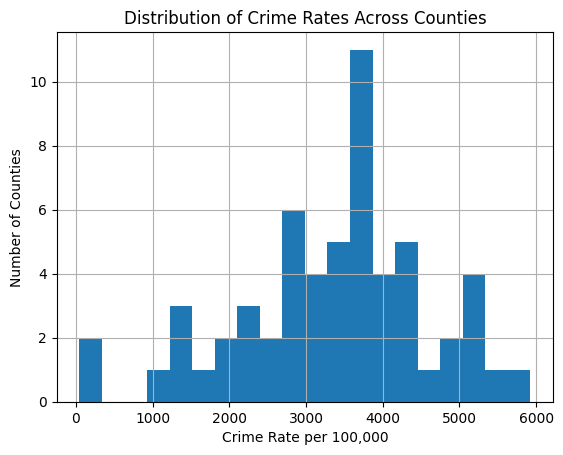

In [15]:
analysis_df["crime_rate"].hist(bins=20)
plt.title("Distribution of Crime Rates Across Counties")
plt.xlabel("Crime Rate per 100,000")
plt.ylabel("Number of Counties")
plt.show()

In [20]:
correlation = analysis_df.corr(numeric_only=True)
correlation

,crime_rate,MEDHHINC_2023,Unemployment_rate_2023,PCTPOVALL_2023,"Percent of adults with a bachelor's degree or higher, 2019-23","Percent of adults who are not high school graduates, 2019-23",Rural_Urban_Continuum_Code_2023
crime_rate,1.000000,-0.184409,0.105831,0.235104,-0.169697,0.130505,0.010788
MEDHHINC_2023,-0.184409,1.000000,-0.521170,-0.777607,0.839899,-0.269086,-0.589143
Unemployment_rate_2023,0.105831,-0.521170,1.000000,0.515206,-0.614540,0.678120,0.139313
PCTPOVALL_2023,0.235104,-0.777607,0.515206,1.000000,-0.606381,0.391691,0.347108
"Percent of adults with a bachelor's degree or higher, 2019-23",-0.169697,0.839899,-0.614540,-0.606381,1.000000,-0.520263,-0.402271
"Percent of adults who are not high school graduates, 2019-23",0.130505,-0.269086,0.678120,0.391691,-0.520263,1.000000,-0.265692
Rural_Urban_Continuum_Code_2023,0.010788,-0.589143,0.139313,0.347108,-0.402271,-0.265692,1.000000


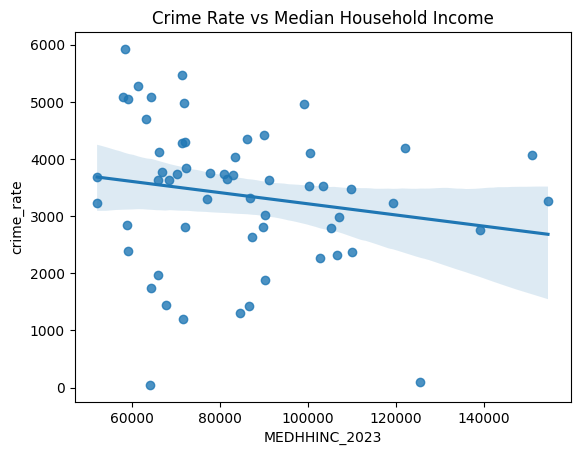

In [22]:
sns.regplot(
    x="MEDHHINC_2023",
    y="crime_rate",
    data=analysis_df
)

plt.title("Crime Rate vs Median Household Income")
plt.show()

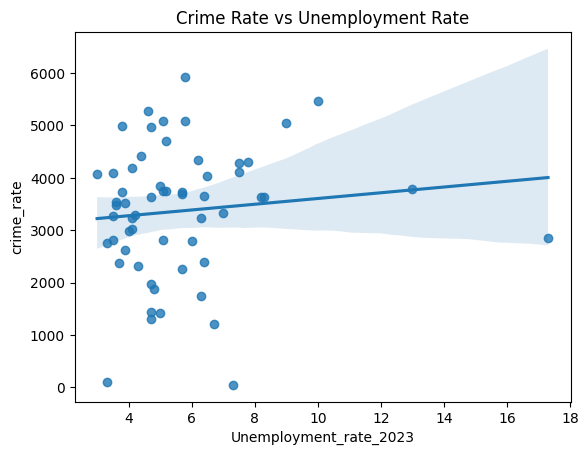

In [23]:
sns.regplot(
    x="Unemployment_rate_2023",
    y="crime_rate",
    data=analysis_df
)

plt.title("Crime Rate vs Unemployment Rate")
plt.show()

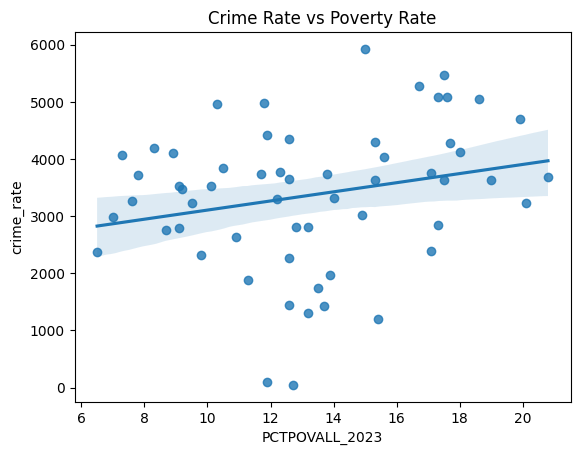

In [24]:
sns.regplot(
    x="PCTPOVALL_2023",
    y="crime_rate",
    data=analysis_df
)

plt.title("Crime Rate vs Poverty Rate")
plt.show()

<Axes: xlabel='MEDHHINC_2023', ylabel='crime_rate'>

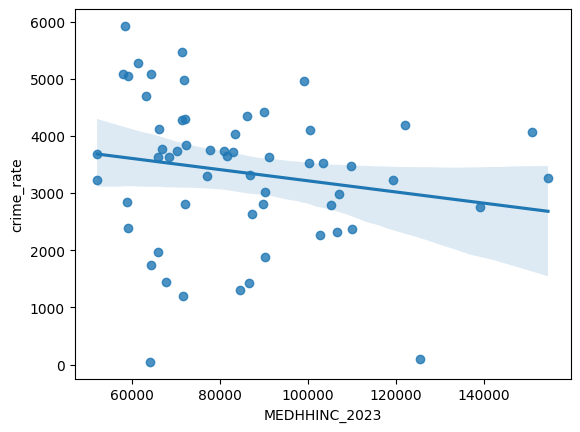

In [78]:
sns.regplot(
    x="MEDHHINC_2023",
    y="crime_rate",
    data=analysis_df
)

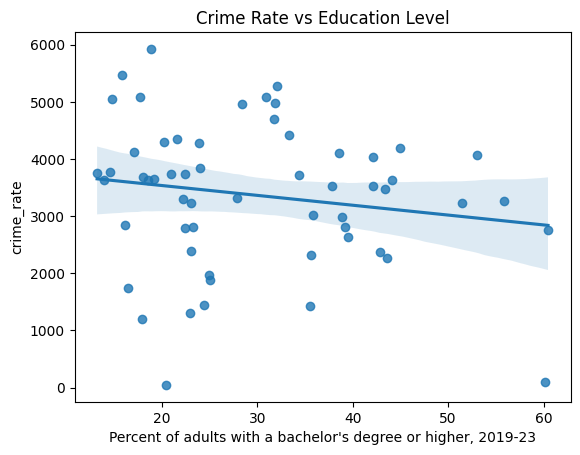

In [26]:
sns.regplot(
    x="Percent of adults with a bachelor's degree or higher, 2019-23",
    y="crime_rate",
    data=analysis_df
)

plt.title("Crime Rate vs Education Level")
plt.show()

In [79]:
analysis_df.groupby("Urban_Category")["crime_rate"].mean()

Urban_Category
Metro       3292.103667
Rural       3112.185406
Suburban    3841.476704
Name: crime_rate, dtype: float64

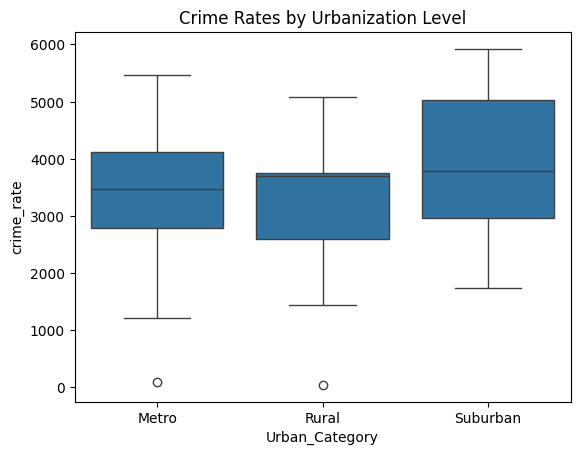

In [27]:
sns.boxplot(
    x="Urban_Category",
    y="crime_rate",
    data=analysis_df
)

plt.title("Crime Rates by Urbanization Level")
plt.show()